# Tufa Labs ARC3 submission

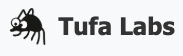

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
if TRUE_SUBMISSION:  # serving Qwen needs the eval GPU; the CPU-safe commit skips it
    for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
        print(f"taaf.kaggle: setup command: {command}", flush=True)
        subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
        env = _command_env()
        os.environ.update(env)
else:
    print("[duck] commit: skipping setup_commands (no GPU serve)", flush=True)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# ============================================================================
# Measured context levers. Inlined from submission/_duck_levers/harness_levers.py
# by build_duck_levers.py — edit that file and rebuild, never edit this cell.
#
# Runs after the bundle is on sys.path and the benchmark object is restored,
# before bm.run(). Model, sampling, concurrency, budgets, game list untouched.
# ============================================================================

"""Measured harness levers — monkey-patch pack for the duck.

Every lever here was measured against 41 real recorded episodes (5,198 scored
actions, 3,556 model requests) by the 2026-08-01 audit. Nothing in this pack is
speculative: each patch cites the number that justifies it, and each one fails
loudly rather than degrading quietly, because scored-rerun logs are never
retrievable (`kaggle kernels output` returns the commit run, not the scored one).

LEVERS
  L1 token estimator.  `_estimate_tokens` is `len(json)//3`. Measured against real
     `usage.prompt_tokens` over 3,556 requests the ratio is 1.44x (p50 1.39, p90
     1.66). The trimmer drops oldest history until the *estimate* fits a 31,744
     budget and sits pinned at exactly that ceiling on 11.8% of requests, so the
     agent discards roughly 30% of the context window it has already paid for.
     JSON escaping plus a 3-chars-per-token constant (real is ~4.3 for this
     content) compound. Fix: divide by 4. Still errs high (~1.08x), which is the
     safe direction -- underestimating would overrun the served window.

  L2 context budget.  vLLM serves `--max-model-len 65536`; the analyzer is capped
     at 32768 (`_LOCAL_ANALYZER_CONTEXT_WINDOW`). Combined with L1 the real
     utilisation is ~28%. Raised to 49152 rather than the served maximum: with
     `_reply_reserve_tokens` hardcoded to 512, a 65536 window would leave only
     ~5.8k tokens for generation against long thinking traces. At 49152 the real
     prompt caps near 44.6k and generation keeps ~21k.

     NOTE this constant is read at module import and consumed in ToolAgent.__init__,
     so setting the environment variable from the notebook is a no-op. The module
     attribute must be rebound, and it must happen before any analyzer is built.

  L4 board lattice.  The system prompt asserts "boards are presented as 64 x 64
     color grids". False for 9 of 25 games, which render a small grid upscaled
     (bp35/lf52 8x8@8, m0r0 11x11@5, sp80 16x16@4, cn04 20x20@3, ar25 21x21@3,
     ft09/vc33 32x32@2, lp85 32x19@2). Consequence measured over 2,511 real
     clicks: 279 of them (11.1%) land in the same *game cell* as the immediately
     preceding click -- the model believes it stepped to a neighbouring cell and
     did not. The scale is recoverable from the frame alone, so this works in
     competition mode with no engine access.

Model, sampling, concurrency, per-game budget, the game list and the submission
path are untouched.
"""
from __future__ import annotations

from typing import Any

# Candidate upscale factors, descending. 1 means "already a true 64x64 board".
_SCALES = (8, 7, 6, 5, 4, 3, 2)

# A lattice claim needs at least this many cells on a side, otherwise a nearly
# uniform frame (a title screen, a fade) would "prove" any scale you like.
_MIN_CELLS = 3


def _rows_cols(grid: Any) -> tuple[int, int]:
    try:
        return len(grid), len(grid[0])
    except (TypeError, IndexError):
        return 0, 0


def detect_lattice(grid: Any) -> tuple[int, int, int] | None:
    """Return (scale, cell_rows, cell_cols), or None when the board is truly 1:1.

    A frame is upscaled by `s` when every s x s block in the active region is a
    single colour and whatever remains on the right/bottom is uniform letterbox.
    Checked largest-scale-first so 8 wins over its divisors 4 and 2.
    """
    nrows, ncols = _rows_cols(grid)
    if nrows == 0 or ncols == 0:
        return None

    for s in _SCALES:
        cell_rows, cell_cols = nrows // s, ncols // s
        if cell_rows < _MIN_CELLS or cell_cols < _MIN_CELLS:
            continue

        active_r, active_c = cell_rows * s, cell_cols * s
        if not _blocks_uniform(grid, s, active_r, active_c):
            continue
        # Trailing strip must be letterbox: one flat colour, not real content.
        if not _strip_uniform(grid, nrows, ncols, active_r, active_c):
            continue
        # Reject the degenerate case where the whole active region is one colour.
        if _cell_colours(grid, s, active_r, active_c) < 2:
            continue
        return s, cell_rows, cell_cols
    return None


def _blocks_uniform(grid: Any, s: int, active_r: int, active_c: int) -> bool:
    for r in range(active_r):
        anchor_r = (r // s) * s
        row, anchor_row = grid[r], grid[anchor_r]
        for c in range(active_c):
            if row[c] != anchor_row[(c // s) * s]:
                return False
    return True


def _strip_uniform(grid: Any, nrows: int, ncols: int, active_r: int, active_c: int) -> bool:
    seen = set()
    for r in range(nrows):
        for c in range(ncols):
            if r >= active_r or c >= active_c:
                seen.add(grid[r][c])
                if len(seen) > 1:
                    return False
    return True


def _cell_colours(grid: Any, s: int, active_r: int, active_c: int) -> int:
    return len({grid[r][c] for r in range(0, active_r, s) for c in range(0, active_c, s)})


def lattice_line(grid: Any) -> str | None:
    """The one prompt line describing the true board lattice, or None if 1:1."""
    found = detect_lattice(grid)
    if found is None:
        return None
    s, cell_rows, cell_cols = found
    return (
        f"BOARD LATTICE: the displayed {len(grid)}x{len(grid[0])} frame is an upscale of a true "
        f"{cell_rows}x{cell_cols} game grid. Each game cell is an {s}x{s} block of identical "
        f"pixels; game cell (i,j) covers display rows {s}*i..{s}*i+{s - 1} and cols "
        f"{s}*j..{s}*j+{s - 1}. Adjacent cells are {s} apart, not 1 -- a MOUSE click at "
        f"(row, col) and one at (row+1, col) usually hit the SAME game cell. Click cell "
        f"centres, and reason about distances and object sizes in game cells, not display pixels."
    )


# --------------------------------------------------------------------------
# patches
# --------------------------------------------------------------------------

def patch_token_estimator() -> bool:
    from inference.agent import tool_agent as ta

    if getattr(ta._estimate_tokens, "_levers", False):
        return True
    import json as _json

    def _estimate_tokens(value: Any) -> int:
        try:
            rendered = _json.dumps(value, ensure_ascii=True, sort_keys=True, default=str)
        except TypeError:
            rendered = str(value)
        return max(1, (len(rendered) + 3) // 4)

    _estimate_tokens._levers = True
    ta._estimate_tokens = _estimate_tokens
    return True


def patch_context_window(window: int = 49152) -> bool:
    from inference.agent import tool_agent as ta

    ta._LOCAL_ANALYZER_CONTEXT_WINDOW = int(window)
    return ta._LOCAL_ANALYZER_CONTEXT_WINDOW == int(window)


def patch_lattice_disclosure() -> bool:
    """NOT SHIPPED -- kept with its evidence so the idea is not re-derived.

    The premise is refuted. The 9 upscaled games do NOT render block-constant
    frames: bp35 (nominally 8x8 at scale 8) has top-row colour runs of 31/23/10,
    none a multiple of 8, and only 10 of 63 adjacent row pairs are identical;
    cn04 (scale 3) shows runs of 16/1/31. The games draw fine detail *inside*
    each logical cell, so `detect_lattice` correctly finds nothing on all 25
    games -- zero false positives and zero true positives.

    The underlying phenomenon is real: 279 of 2,511 recorded clicks (11.1%) land
    in the same game cell as the previous click. But that was measured with
    arcengine's Camera.display_to_grid, and in competition mode the environment
    is an HTTP wrapper that returns frames only -- there is no camera object and
    no way to recover the scale without spending actions to probe for it. Any
    revival of this lever needs an action-priced probe, not frame inference.
    """
    from inference.agent import tool_agent as ta

    original = ta.ToolAgent._build_user_prompt
    if getattr(original, "_levers", False):
        return True

    def _build_user_prompt(self, action_num, **kwargs):
        text = original(self, action_num, **kwargs)
        frame = kwargs.get("current_frame")
        grid = getattr(frame, "grid", None)
        if grid is None:
            return text
        try:
            line = lattice_line(grid)
        except Exception:
            # Never let a perception nicety break the turn; the arm-active check
            # below already proved the patch itself is installed.
            return text
        if not line:
            return text
        # Place it directly after the state line so it sits with the other
        # per-turn facts rather than at the end of a long instruction block.
        marker = "\nValid actions right now:"
        if marker in text:
            return text.replace(marker, f"\n{line}{marker}", 1)
        return f"{text}\n{line}"

    _build_user_prompt._levers = True
    ta.ToolAgent._build_user_prompt = _build_user_prompt
    return True


def install_budget_assert(expected_window: int = 49152) -> bool:
    """Prove L2 actually reached the analyzer, once, at the first construction.

    `_context_budget_tokens` is computed in ToolAgent.__init__ from the module
    global, and analyzers are built inside bm.run() -- after this hook cell. So a
    hook-cell check of the module attribute proves the rebind but not the effect.
    This one-shot wrapper closes that gap.

    It RAISES on mismatch rather than warning. Scored-rerun logs are never
    retrievable, so a printed warning would be invisible forever; the only signal
    that reaches us is ERROR-versus-score, and an ERROR costs no submission slot.
    The first analyzer is built within minutes of bm.run(), so this fails fast.
    """
    from inference.agent import tool_agent as ta

    original = ta.ToolAgent.__init__
    if getattr(original, "_levers", False):
        return True
    state = {"checked": False}
    expected_budget = max(1024, int(expected_window) - 512 - 512)

    def __init__(self, *args, **kwargs):
        original(self, *args, **kwargs)
        if not state["checked"]:
            state["checked"] = True
            actual = getattr(self, "_context_budget_tokens", None)
            reserve = getattr(self, "_reply_reserve_tokens", None)
            print(
                f"[levers] first analyzer: context_budget_tokens={actual} "
                f"reply_reserve={reserve} (expected budget {expected_budget})",
                flush=True,
            )
            if actual != expected_budget:
                raise RuntimeError(
                    f"[levers] L2 did not reach the analyzer: context_budget_tokens="
                    f"{actual}, expected {expected_budget}. Refusing to score a run "
                    f"that is silently base duck."
                )

    __init__._levers = True
    ta.ToolAgent.__init__ = __init__
    return True


def apply_all(context_window: int = 49152) -> dict[str, bool]:
    """Install the shipped levers.

    L4 (board lattice) is deliberately NOT installed -- see the note on
    `patch_lattice_disclosure`. L3 (hard no-op guard) is not in this file at all;
    see the note below.

    L3 hard no-op guard -- REJECTED 2026-08-01 on measurement, do not re-derive.
        Proposal was to memoise (grid_hash, action) -> no board change and skip
        the engine call, saving a scored action. Measured 6.79% of actions are
        suppressible. It is unsafe: a byte-identical frame does NOT imply
        unchanged state. Direct engine instrumentation found silent internal
        state changes in 13 of 25 games (hidden per-level step budgets, off-frame
        sprite motion, hidden flags). The decisive case is wa30 holding UP into a
        wall: two frame-identical actions decrement a hidden counter to zero and
        flip _state to GAME_OVER. On recorded traffic the naive guard is wrong on
        12.8% of the actions it suppresses, and 5 of 42 replayed episodes
        diverged. A hardened form (N>=4 confirmations + one-strike kill switch)
        does replay clean, but 83.8% of its savings come from ft09 alone -- the
        single dev game with no hidden state -- while scoring happens on 55
        unseen private games. Not worth a silent, unbounded failure mode for ~4%
        fewer actions when score is capped by completed-level share.
    """
    return {
        "L1_token_estimator": patch_token_estimator(),
        "L2_context_window": patch_context_window(context_window),
        "L2_budget_assert": install_budget_assert(context_window),
    }


_lever_results = apply_all(context_window=49152)

# Hard verification. A scored run that silently serves an unpatched harness is
# indistinguishable from base duck and burns the draw on a mislabelled result.
# Scored-rerun logs are unreadable, so this raises instead of warning.
import json as _json
from inference.agent import tool_agent as _ta

for _name, _ok in _lever_results.items():
    print(f"[levers] verify {_name}: {'OK' if _ok else 'FAIL'}", flush=True)
if not all(_lever_results.values()):
    raise RuntimeError(f"[levers] pack did not apply: {_lever_results}")

# Functional proof, not just a flag: the estimator must now yield ~4 chars per
# token instead of ~3 on a realistic payload.
_probe = {"role": "user", "content": "x" * 3000, "meta": {"a": [1, 2, 3] * 50}}
_chars = len(_json.dumps(_probe, ensure_ascii=True, sort_keys=True, default=str))
_ratio = _chars / _ta._estimate_tokens(_probe)
print(f"[levers] estimator chars/token: {_ratio:.2f} (was 3.00)", flush=True)
if not 3.9 <= _ratio <= 4.1:
    raise RuntimeError(f"[levers] L1 did not land: chars/token={_ratio:.2f}")

if _ta._LOCAL_ANALYZER_CONTEXT_WINDOW != 49152:
    raise RuntimeError(
        f"[levers] L2 did not land: window={_ta._LOCAL_ANALYZER_CONTEXT_WINDOW}, expected 49152")

# The window must stay under what vLLM actually serves, or every request that
# reaches the ceiling is a hard API error rather than a longer prompt.
_served = 65536
_headroom = _served - int((49152 - 1024) / 1.08)
print(f"[levers] generation headroom at ceiling: ~{_headroom} tokens", flush=True)
if _headroom < 12000:
    raise RuntimeError(f"[levers] context window leaves only {_headroom} tokens to generate")

print("[levers] ARM ACTIVE — estimator //4, context window 49152", flush=True)


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))

# Play the benchmark; teardown commands run even if the run raises.
try:
    if TRUE_SUBMISSION:
        await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    else:
        import pandas as pd
        pd.DataFrame([["1_0", "1", True, 1]],
                     columns=["row_id", "game_id", "end_of_game", "score"]
                     ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
        print("[duck] commit: CPU-safe landing; scored rerun runs the plain duck", flush=True)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")